In [1]:
using DifferentialEquations
using GLMakie
import GeometryBasics
using GeometryBasics: Cylinder, Cone, Vec3f
using Distributions
using Observables
using Plots

In [2]:
mypelette = cgrad([:white, :yellow, :orange], [0.001, 0.1, 1])

In [3]:
function rossler!(du, u, p, t)
    a, b, c = p
    du[1] = -u[2] - u[3]
    du[2] = u[1] + a*u[2]
    du[3] = b + u[3]*(u[1] - c)
end

rossler! (generic function with 1 method)

In [30]:
tf = 150; 
dt = 0.005;
tspan = (0, tf)

u0 = rand(Uniform(0.1, 1), 3)
u0[3] = 0;

In [31]:
a, b, c = 0.2, 0.2, 5.7;

p = (a, b, c)

prob = ODEProblem(rossler!, u0, tspan, p)
sol = solve(prob, Tsit5(), saveat=dt);

traj = Array(sol)';

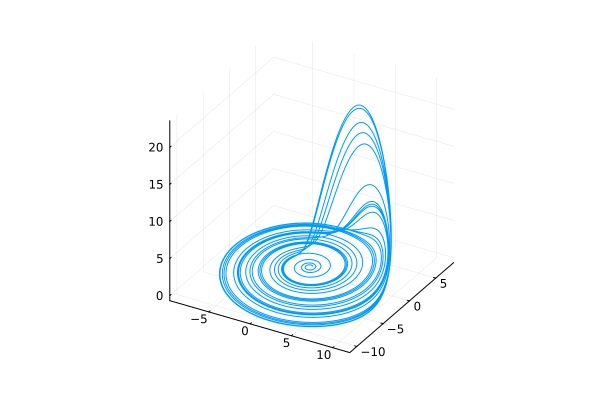

In [32]:
Plots.plot(traj[:, 1], traj[:, 2], traj[:, 3], label="")

In [56]:

function create_frame(pplot1)
    global widths
    
    for width in widths
        alphaa = get_alpha_grad(width)
        pplot1 = plot!(sol[:, 1], sol[:, 2], sol[:, 3], lw=width, c=mypelette[1-alphaa], label="", alpha=alphaa)
    end
end

create_frame (generic function with 1 method)

In [7]:
widths = LinRange(80, 0.8, 30)

anim = @animate for i=0:10
    print("\r$(i)")
    pplot = plot()
    create_frame(pplot)
    pplot = plot!(camera=(i, 5), zlim=(-0.02, maximum(sol[:, 3])+0.02), ylim=(-12, 12), xlim=(-12, 12), 
                    grid=:none, margins=0Plots.mm, pad_inches=0, axis=false, background=:black, dpi=300)

end

mp4(anim)


LoadError: LoadError: UndefVarError: `@animate` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at In[7]:3

In [192]:


function create_roc1(x, y, z, tangent)
    R = align_matrix(tangent)
    trans = Translation(x, y, z)
    cyl = mesh(Cylinder(Point3f0(0,0,0), Point3f0(0,0,1), 0.2),
               transformation = trans ∘ R)
    cone = mesh(Cone(Point3f0(0,0,1), Point3f0(0,0,1.5), 0.3),
                transformation = trans ∘ R)
    return cyl, cone
end


create_roc1 (generic function with 1 method)

In [7]:
cyl, cone_cap = create_roc(traj[end-200, 1], traj[end-200, 2], traj[end-200, 3])

println("Done///")
fig = Figure(size=(800, 800))
axs = Axis3(fig[1, 1], aspect=(1, 1, 1), azimuth=189, elevation=0.2)

lines!(axs, traj[:, 1], traj[:, 2], traj[:, 3], label="")
mesh!(axs, cone_cap)
mesh!(axs, cyl)

Done///


Mesh{Tuple{GeometryBasics.Mesh{3, Float32, GeometryBasics.NgonFace{3, GeometryBasics.OffsetInteger{-1, UInt32}}, (:position, :normal), Tuple{Vector{Point{3, Float32}}, Vector{Vec{3, Float32}}}, Vector{GeometryBasics.NgonFace{3, GeometryBasics.OffsetInteger{-1, UInt32}}}}}}

In [8]:
srn = display(fig)

GLMakie.Screen(...)

In [9]:
GLMakie.destroy!(srn)

In [17]:

fig1 = Figure(size=(800, 800))
ax = Axis3(fig1[1, 1], aspect=(1, 1, 1), azimuth=189, elevation=0.2)

record(fig1, "rocket.mp4", 1:20) do i
    print("\r$(i)")

    
    ax = Axis3(fig1[1, 1], aspect=(1, 1, 1), azimuth=189, elevation=0.2)
    
    lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3])
    cyl, cone = create_roc(traj[i, 1], traj[i, 2], traj[i, 3])
    mesh!(ax, cyl)
    mesh!(ax, cone)
end


20

"rocket.mp4"

In [10]:
function create_roc(xpos, ypos, zpos)
    Cone(; quality = 10) = merge([
    Makie._circle(Point3f(xpos, ypos, zpos+0.25), 0.5f0, Vec3f(xpos,ypos,zpos-1.25), quality),
    Makie._mantle(Point3f(xpos, ypos, zpos), Point3f(xpos,ypos,zpos+2f0), 0.5f0, 0f0, quality)])
    cone_cap1 = Cone()

    cyl1 = Cylinder(Point3f(xpos, ypos, zpos+0.25), Point3f(xpos, ypos, zpos-1.25), 0.5f0)
    return cyl1, cone_cap1
end

function get_alpha_grad(xx)
    return exp.(-0.06 .* (xx.-2))
end

function neon_lines!(ax1, x, y, z, widths)
    alphas = get_alpha_grad(widths)
    for w in widths
        alphaa = get_alpha_grad(w)
        lines!(ax1, x, y, z;
            linewidth = w,
            color = mypelette[1-alphaa],
            alpha = alphaa,
            transparency = true)  # alpha blending
    end
    # return ax1
end

neon_lines! (generic function with 1 method)

In [166]:
widths[end], get_alpha_grad(widths[end])

(2.0, 1.0)

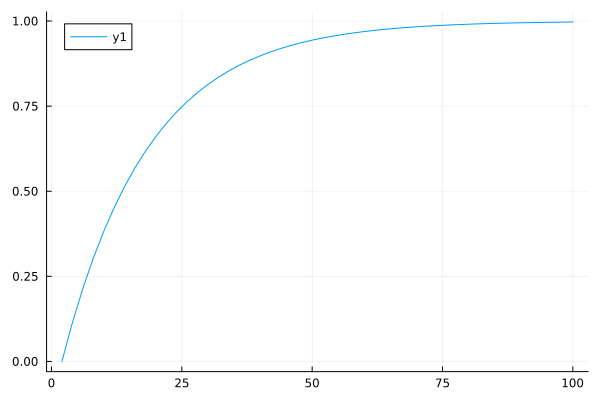

In [158]:
Plots.plot(widths, 1 .- get_alpha_grad(widths))

In [8]:
widths = LinRange(120, 2, 18)

fig = Figure(size=(1800, 1500), backgroundcolor=:black, perspectiveness=0.2)
ax = Axis3(fig[1, 1], aspect=(1, 1, 1),
            azimuth=189, elevation=0.2)

hidedecorations!(ax)
hidespines!(ax)
GLMakie.xlims!(ax, minimum(traj[:, 1])-2, maximum(traj[:, 1])+2)
GLMakie.ylims!(ax, minimum(traj[:, 2])-2, maximum(traj[:, 2])+2)
GLMakie.zlims!(ax,minimum(traj[:, 3])-2, maximum(traj[:, 3])+4)
# ax. = false
# create_MK_frame(ax)
# lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3], linewidth=5, color=:orange, alpha=0.1)
# lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3], linewidth=3, color=:yellow, alpha=0.5)
# lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3], linewidth=8, color=:yellow, alpha=0.1, depth_write=false)
# lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3], linewidth=5, color=:yellow, alpha=0.5)
# lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3], linewidth=2, color=:yellow, alpha=1)
neon_lines!(ax, traj[:,1], traj[:,2], traj[:,3], widths)

for ii=1:8
    lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3], linewidth=2, color=:white, alpha = 1,
            transparency = true)
end
# lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3], linewidth=2, color=:white, alpha = 1,
#             transparency = true)
# lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3], linewidth=2, color=:white, alpha = 1,
            # transparency = true)


cyl0, cone0 = create_roc(traj[1, 1], traj[1, 2], traj[1, 3])
cyl_obs  = Observable(cyl0)
cone_obs = Observable(cone0)

mesh!(ax, cyl_obs)
mesh!(ax, cone_obs)

record(fig, "rocket.mp4", framerate=100, 22300:4:22800) do i
    print("\r$(i)")
    cyl, cone = create_roc(traj[i,1], traj[i,2], traj[i,3])
    cyl_obs[]  = cyl
    cone_obs[] = cone

    ax.elevation[] = 0.1 + 0.1 * sin(2π * i/2000)

    ax.azimuth[] = -2π * i/5000
end


22800

"rocket.mp4"

(30001, 3)

In [36]:
using LinearAlgebra
function create_roc1(pos, dir)
    d = normalize(Vec3f(dir...))
    p = Point3f(pos...)
    

    len_cyl  = 2f0
    rad      = 1.0f0
    len_cone = 1.5f0

    p1 = p - d * 0.25f0
    p2 = p - d * (0.25f0 + len_cyl)

    cyl  = Cylinder(p1, p2, rad)
    cone = Makie._mantle(p, p + d * len_cone, rad, 0f0, 10)

    return cyl, cone
end

function create_roc_with_tail(pos, dir)
    # Convert to Vec3f
    d = normalize(Vec3f(Float32.(dir)...))
    p = Point3f(Float32.(pos)...)

    # rocket dimensions
    len_cyl  = 1.5f0
    rad      = 0.5f0
    len_cone = 2f0
    tail_len = 3.0f0

    # rocket cylinder/cone
    cyl  = Cylinder(p - d*0.25f0, p - d*(0.5f0+len_cyl), rad)
    cone = Makie._mantle(p, p + d*len_cone, rad, 0f0, 30)

    # tail behind rocket
    tail_cone = Makie._mantle(p - d*0.25f0, p - d*(0.25f0+tail_len), rad*0.3f0, 0f0, 8)

    return cyl, cone, tail_cone
end


create_roc_with_tail (generic function with 1 method)

In [ ]:
widths = LinRange(120, 2, 18)

fig = Figure(size=(1800, 1500), backgroundcolor=:black, perspectiveness=0.2)
ax = Axis3(fig[1, 1], aspect=:data,
            azimuth=189, elevation=0.2)

hidedecorations!(ax)
hidespines!(ax)
GLMakie.xlims!(ax, minimum(traj[:, 1])-2, maximum(traj[:, 1])+2)
GLMakie.ylims!(ax, minimum(traj[:, 2])-2, maximum(traj[:, 2])+2)
GLMakie.zlims!(ax,minimum(traj[:, 3])-2, maximum(traj[:, 3])+4)


neon_lines!(ax, traj[:,1], traj[:,2], traj[:,3], widths)

for ii=1:20
    lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3], linewidth=2, color=:white, alpha = 1,
            transparency = true)
end
# lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3], linewidth=2, color=:white, alpha = 1,
#             transparency = true)
# lines!(ax, traj[:, 1], traj[:, 2], traj[:, 3], linewidth=2, color=:white, alpha = 1,
            # transparency = true)

startframe = 12000; endframe = 26000; 

rocket_color = RGBAf(0.0, 1.0, 1.0, 1.0)  # bright cyan
tail_color   = RGBAf(1.0, 0.3, 0.0, 0.8)  # reddish-orange

cyl0, cone0, tail0 = create_roc_with_tail(Tuple(traj[startframe,:]), Tuple(traj[startframe+1,:] .- traj[startframe,:]))
cyl_obs  = Observable(cyl0)
cone_obs = Observable(cone0)
tail_obs = Observable(tail0)

mesh!(ax, cyl_obs, color=rocket_color)
mesh!(ax, cone_obs, color=rocket_color)
mesh!(ax, tail_obs, color=tail_color)

record(fig, "ross_rocket.mp4", framerate=120, startframe:3:endframe) do i
    print("\r$(i)")
    pos = Tuple(traj[i, :])
    dir = Tuple(traj[i+1, :] .- traj[i, :])

    cyl, cone, tail = create_roc_with_tail(pos, dir)

    cyl_obs[]  = cyl
    cone_obs[] = cone
    tail_obs[] = tail

    ax.elevation[] = 0.1 + 0.1 * sin(2π * i/6000)

    ax.azimuth[] = -2π * i/12000
end


25998

"rocket.mp4"